In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers = pd.read_csv("customers_cleaned.csv")
cards = pd.read_csv("cards_cleaned.csv")
payments = pd.read_csv("payments_cleaned.csv")
transactions = pd.read_csv("transactions_cleaned.csv")

## EDA

we have already done the initial exploration of the data and we know that there are no nan, duplicated, missing values, standardize the categorical columns, converted date time.

1. now we start with customers table and check for outliers 


In [3]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 9385 entries, 0 to 9384
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         9385 non-null   int64  
 1   customer_id        9385 non-null   int64  
 2   first_name         9385 non-null   str    
 3   last_name          9385 non-null   str    
 4   gender             9385 non-null   str    
 5   customer_age       9385 non-null   int64  
 6   marital_status     9385 non-null   str    
 7   education_level    9385 non-null   str    
 8   employment_status  9385 non-null   str    
 9   annual_income      9385 non-null   float64
 10  credit_score       9385 non-null   int64  
 11  email              9385 non-null   str    
 12  city               9385 non-null   str    
 13  state              9385 non-null   str    
dtypes: float64(1), int64(4), str(9)
memory usage: 1.0 MB


<Axes: >

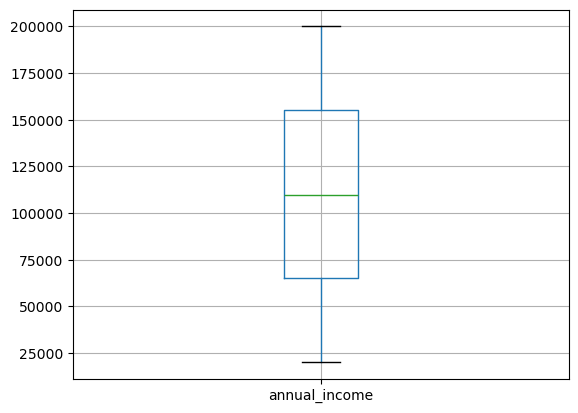

In [4]:
customers.boxplot(column = "annual_income")

no outliers in customers annual_income

In [5]:
cards.info()

<class 'pandas.DataFrame'>
RangeIndex: 11790 entries, 0 to 11789
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           11790 non-null  int64  
 1   card_id              11790 non-null  int64  
 2   customer_id          11790 non-null  int64  
 3   card_type            11790 non-null  str    
 4   card_network         11790 non-null  str    
 5   card_number          11790 non-null  int64  
 6   account_open_date    11790 non-null  str    
 7   credit_limit         11790 non-null  int64  
 8   available_credit     11790 non-null  int64  
 9   interest_rate        11790 non-null  float64
 10  annual_fee           11790 non-null  float64
 11  minimum_payment_due  11790 non-null  int64  
 12  card_status          11790 non-null  str    
 13  account_open_year    11790 non-null  int64  
 14  account_open_month   11790 non-null  int64  
dtypes: float64(2), int64(9), str(4)
memory usage: 1

In [6]:
payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           10000 non-null  int64  
 1   payment_id           10000 non-null  int64  
 2   card_id              10000 non-null  int64  
 3   billing_cycle_start  10000 non-null  str    
 4   billing_cycle_end    10000 non-null  str    
 5   minimum_payment_due  10000 non-null  int64  
 6   payment_amount       10000 non-null  int64  
 7   payment_method       10000 non-null  str    
 8   payment_status       10000 non-null  str    
 9   late_payment_flag    10000 non-null  float64
 10  days_past_due        10000 non-null  int64  
dtypes: float64(1), int64(6), str(4)
memory usage: 859.5 KB


In [7]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 68602 entries, 0 to 68601
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          68602 non-null  int64  
 1   transaction_id      68602 non-null  int64  
 2   card_id             68602 non-null  int64  
 3   transaction_date    68602 non-null  str    
 4   transaction_amount  68602 non-null  float64
 5   merchant_name       68602 non-null  str    
 6   merchant_category   58705 non-null  str    
 7   merchant_city       68602 non-null  str    
 8   merchant_country    68602 non-null  str    
 9   currency            68602 non-null  str    
 10  fraud_flag          68602 non-null  float64
 11  transaction_status  51370 non-null  str    
 12  transaction_year    68602 non-null  int64  
 13  transaction_month   68602 non-null  int64  
dtypes: float64(2), int64(5), str(7)
memory usage: 7.3 MB


## Analytical Questions : Customer Analytics

1. Who are the highest spending customers?
2. What customer segments generate the most revenue?
3. How does income relate to credit utilization?

In [8]:
transactions_with_customers = pd.merge(
    transactions,
    cards[['card_id','customer_id']],
    on = 'card_id',
    how = 'left'
)

In [9]:
transactions_with_customers = transactions_with_customers[transactions_with_customers['transaction_amount'] > 0]

In [10]:
customer_spending = transactions_with_customers.groupby('customer_id')['transaction_amount'].sum().reset_index()
customer_spending.rename(columns = {'transaction_amount':'total_spending'}, inplace = True)

In [11]:
customer_spending.head(10)

,customer_id,total_spending
0,2.0,6177.87
1,4.0,11955.53
2,5.0,18239.41
3,6.0,8330.10
4,7.0,8192.93
5,8.0,17701.26
6,9.0,3700.11
7,10.0,6542.60
8,11.0,4413.53
9,12.0,18158.64


## Analytical Questions : Customer Analytics

1. Who are the highest spending customers?
2. What customer segments generate the most revenue?
3. How does income relate to credit utilization?

In [16]:
transactions_with_customer = pd.merge(
    transactions, 
    cards[['card_id','customer_id']], 
    on='card_id', 
    how='left'
)

transactions_with_customer = transactions_with_customer[transactions_with_customer['transaction_amount'] > 0]
transactions_with_customer = transactions_with_customer.dropna(subset=['customer_id'])

customer_spending = transactions_with_customer.groupby('customer_id')['transaction_amount'].sum().reset_index()
customer_spending.rename(columns={'transaction_amount':'total_spending'}, inplace=True)

In [21]:
customer_profile = pd.merge(customers, customer_spending, on='customer_id', how='left')
customer_profile['total_spending'] = customer_profile['total_spending'].fillna(0)

In [22]:
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-25','26-35','36-45','46-55','56-65','65+']
customer_profile['age_group'] = pd.cut(customer_profile['customer_age'], bins=bins, labels=labels)

In [23]:
income_bins = [0, 50000, 100000, 150000, 200000, 500000]
income_labels = ['<50k','50k-100k','100k-150k','150k-200k','200k+']
customer_profile['income_group'] = pd.cut(customer_profile['annual_income'], bins=income_bins, labels=income_labels)

In [24]:
age_segment_spending = customer_profile.groupby('age_group')['total_spending'].sum().reset_index()
age_segment_spending = age_segment_spending.sort_values(by='total_spending', ascending=False)

In [25]:
# By gender
gender_spending = customer_profile.groupby('gender')['total_spending'].sum().sort_values(ascending=False)

# By income group
income_spending = customer_profile.groupby('income_group')['total_spending'].sum().sort_values(ascending=False)

# By marital status
marital_spending = customer_profile.groupby('marital_status')['total_spending'].sum().sort_values(ascending=False)

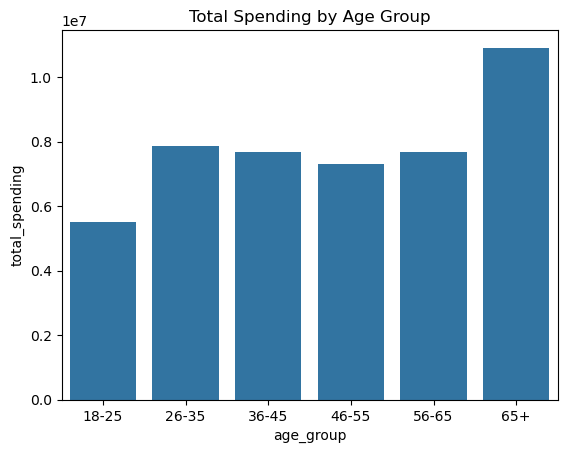

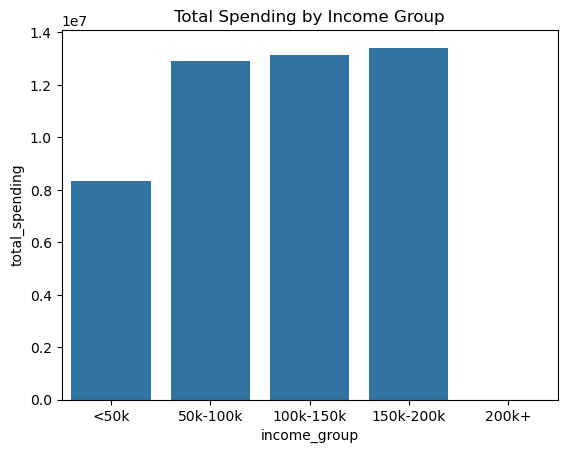

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Age group
sns.barplot(x='age_group', y='total_spending', data=age_segment_spending)
plt.title("Total Spending by Age Group")
plt.show()

# Income group
sns.barplot(x='income_group', y='total_spending', data=income_spending.reset_index())
plt.title("Total Spending by Income Group")
plt.show()

## Analytical Questions : Customer Analytics

1. Who are the highest spending customers?
2. What customer segments generate the most revenue?
3. How does income relate to credit utilization?

In [31]:
cards['Credit_Utilization'] = (cards['credit_limit']-cards['available_credit'])/cards['credit_limit']

In [32]:
cards['Credit_Utilization'] = cards['Credit_Utilization'].replace([np.inf, -np.inf], np.nan).fillna(0)

In [33]:
customer_utilization = cards.groupby('customer_id')['Credit_Utilization'].mean().reset_index()

In [34]:
income_vs_util = customer_utilization.merge(
    customers[['customer_id', 'annual_income']], on='customer_id', how='left'
)

In [36]:
income_vs_util[['annual_income','Credit_Utilization']].corr()

,annual_income,Credit_Utilization
annual_income,1.000000,-0.008492
Credit_Utilization,-0.008492,1.000000


<Figure size 800x500 with 0 Axes>

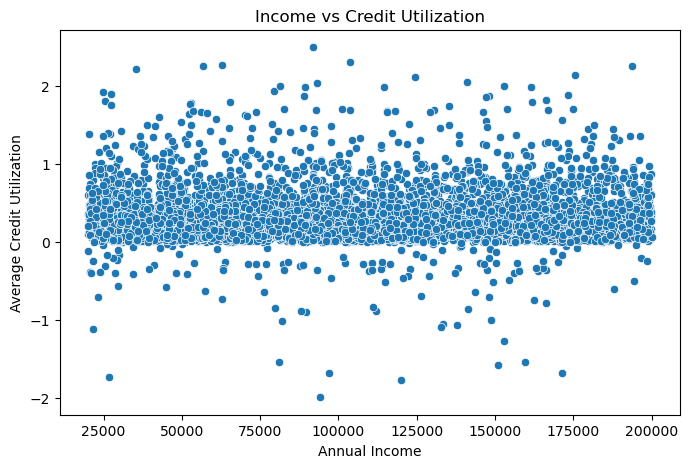

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(x='annual_income', y='Credit_Utilization', data=income_vs_util)
plt.title('Income vs Credit Utilization')
plt.xlabel('Annual Income')
plt.ylabel('Average Credit Utilization')
plt.show()

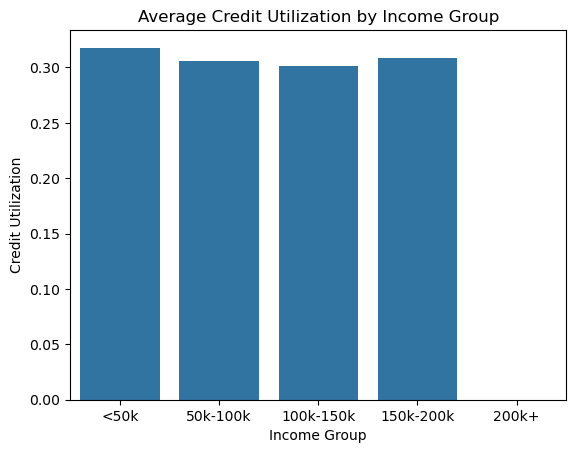

In [39]:
# Define income brackets
bins = [0, 50000, 100000, 150000, 200000, 500000]
labels = ['<50k','50k-100k','100k-150k','150k-200k','200k+']
income_vs_util['income_group'] = pd.cut(income_vs_util['annual_income'], bins=bins, labels=labels)

# Average utilization per income group
avg_util = income_vs_util.groupby('income_group')['Credit_Utilization'].mean().reset_index()

sns.barplot(x='income_group', y='Credit_Utilization', data=avg_util)
plt.title('Average Credit Utilization by Income Group')
plt.ylabel('Credit Utilization')
plt.xlabel('Income Group')
plt.show()